# Initialization

In [ ]:
file_path = '/content/drive/MyDrive/FYP/'
melBERT_path = '/MelBERT-main/saves/roberta-base/6_20260331-0430/'

In [ ]:
!pip install -q flax
!pip install -q transformers==4.38.2
!pip install -q scikit-multilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Import neccessary libraries
import time, os, torch, copy, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModel, AutoConfig
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, hamming_loss, multilabel_confusion_matrix
)
from skmultilearn.model_selection import IterativeStratification
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed datasets
path_df_small = file_path + 'df_small.pkl'
path_df_big = file_path + 'df_big.pkl'

# Load the ready-to-use dataframes
df_small = pd.read_pickle(path_df_small)
df_big = pd.read_pickle(path_df_big)

# System Specifications




In [ ]:
print("--- CPU Information ---")
!lscpu | grep 'Model name\|Architecture\|CPU(s)\|Core(s) per socket\|Thread(s) per core'

print("\n--- Memory Information ---")
!free -h

--- CPU Information ---
Architecture:                            x86_64
CPU(s):                                  12
On-line CPU(s) list:                     0-11
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
Thread(s) per core:                      2
Core(s) per socket:                      6
NUMA node0 CPU(s):                       0-11

--- Memory Information ---
               total        used        free      shared  buff/cache   available
Mem:           167Gi       2.6Gi       157Gi       2.0Mi       6.8Gi       163Gi
Swap:             0B          0B          0B


## GPU Information

In [ ]:
import torch

print("--- GPU Information ---")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    !nvidia-smi
else:
    print("No GPU detected or CUDA is not available. Please check your Colab runtime type.")

--- GPU Information ---
GPU Name: NVIDIA A100-SXM4-80GB
GPU Memory Total: 79.25 GB
Thu Apr 16 08:30:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             53W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |              

# Testing datasets

In [ ]:
print("df_small columns:")
print(df_small.columns)
print()
print("df_big columns:")
print(df_big.columns)
print()
print(f"Number of rows for df_small: {len(df_small)}")
print(f"Number of rows for df_big  : {len(df_big)}")

df_small columns:
Index(['statement', 'Anxiety', 'Bipolar', 'Depression', 'Normal',
       'Personality disorder', 'Stress', 'Suicidal'],
      dtype='object')

df_big columns:
Index(['Text', 'Anxiety', 'BPD', 'autism', 'bipolar', 'depression',
       'mentalhealth', 'schizophrenia'],
      dtype='object')

Number of rows for df_small: 51073
Number of rows for df_big  : 486475


# Determine if a sliding window is needed for the dataset

In [ ]:
# Load the specific PsychBERT tokenizer
psychbert_tokenizer = AutoTokenizer.from_pretrained("mnaylor/psychbert-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def get_exact_token_count(text, tokenizer=psychbert_tokenizer):
    # .encode converts text to tokens.
    # add_special_tokens=True ensures it counts the [CLS] and [SEP] tokens BERT uses.
    # Notice we do NOT use max_length or truncation here.
    tokens = tokenizer.encode(str(text), add_special_tokens=True)
    return len(tokens)

df_small_exact_token_count = df_small.copy()
df_big_exact_token_count = df_big.copy()

# Apply this function to your text column to create a new column with exact counts
df_small_exact_token_count['exact_token_count'] = df_small_exact_token_count['statement'].apply(get_exact_token_count)
df_big_exact_token_count['exact_token_count'] = df_big_exact_token_count['Text'].apply(get_exact_token_count)

# Now, filter the dataframe to see exactly which rows are over the limit
over_limit_df_small = df_small_exact_token_count[df_small_exact_token_count['exact_token_count'] > 512]
over_limit_df_big = df_big_exact_token_count[df_big_exact_token_count['exact_token_count'] > 512]

print(f"Total rows in small dataset: {len(df_small)}")
print(f"Rows exceeding 512 tokens for small dataset: {len(over_limit_df_small)}")
print()
print(f"Total rows in big dataset: {len(df_big)}")
print(f"Rows exceeding 512 tokens for big dataset: {len(over_limit_df_big)}")

# Look at the lengths of the ones that are too long
if len(over_limit_df_small) > 0:
    print("\nExact token counts of the overflowing rows for small dataset:")
    print(over_limit_df_small['exact_token_count'].head())
print()
if len(over_limit_df_big) > 0:
    print("\nExact token counts of the overflowing rows for small dataset:")
    print(over_limit_df_big['exact_token_count'].head())

Token indices sequence length is longer than the specified maximum sequence length for this model (815 > 512). Running this sequence through the model will result in indexing errors


Total rows in small dataset: 51073
Rows exceeding 512 tokens for small dataset: 2121

Total rows in big dataset: 486475
Rows exceeding 512 tokens for big dataset: 52052

Exact token counts of the overflowing rows for small dataset:
118     815
153    1388
168     720
227     635
235    1580
Name: exact_token_count, dtype: int64


Exact token counts of the overflowing rows for small dataset:
27    3863
36    2092
37     628
52     702
67    1204
Name: exact_token_count, dtype: int64


# Parsing MelBERT training weights and Setting up Model Weights

In [ ]:
# Check if the MelBERT checkpoint actually contains the expected weights
checkpoint_path = file_path + melBERT_path + "pytorch_model.bin"
try:
    # Corrected map_location argument
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    print(f"Total keys in checkpoint: {len(state_dict.keys())}")
    print("First 10 keys:")
    print(list(state_dict.keys())[:10])
except Exception as e:
    print(f"Could not load checkpoint directly: {e}")

Total keys in checkpoint: 205
First 10 keys:
['encoder.embeddings.word_embeddings.weight', 'encoder.embeddings.position_embeddings.weight', 'encoder.embeddings.token_type_embeddings.weight', 'encoder.embeddings.LayerNorm.weight', 'encoder.embeddings.LayerNorm.bias', 'encoder.encoder.layer.0.attention.self.query.weight', 'encoder.encoder.layer.0.attention.self.query.bias', 'encoder.encoder.layer.0.attention.self.key.weight', 'encoder.encoder.layer.0.attention.self.key.bias', 'encoder.encoder.layer.0.attention.self.value.weight']


In [ ]:
# 1. Load PsychBERT
psychbert_model = AutoModel.from_pretrained('mnaylor/psychbert-cased', from_flax=True)

# 2. Load MelBERT with configuration adjustment
melbert_path = file_path + melBERT_path
checkpoint_file = f"{melbert_path}/pytorch_model.bin"

# Load config and adjust type_vocab_size to 4 to match your checkpoint
config = AutoConfig.from_pretrained('roberta-base')
config.type_vocab_size = 4

# Initialize model with the adjusted config and ignore size mismatches during initial weight load
melbert_model = AutoModel.from_pretrained('roberta-base', config=config, ignore_mismatched_sizes=True)

# Load state dict and strip the 'encoder.' prefix
state_dict = torch.load(checkpoint_file, map_location='cpu')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('encoder.'):
        new_state_dict[k[8:]] = v
    else:
        new_state_dict[k] = v

# Load the fixed state dict
msg = melbert_model.load_state_dict(new_state_dict, strict=False)
print("MelBERT loading report:", msg)

bert_model = AutoModel.from_pretrained("bert-base-uncased")
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


flax_model.msgpack:   0%|          | 0.00/433M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_flax_pytorch_utils.py:460: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  pt_model_dict[flax_key] = torch.from_numpy(flax_tensor)
Some weights of the Flax model were not used when initializing the PyTorch model BertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from a Flax model trained on another task or with another architecture (e.g. initializing 

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Model Architecture

In [ ]:
class ChunkedDataset(Dataset):
    def __init__(self, dataframe, text_col, label_cols, chunk_len=256, stride=50, max_chunks=4):
        self.text = dataframe[text_col].values
        self.labels = dataframe[label_cols].values

        self.tokenizer_psych = AutoTokenizer.from_pretrained("mnaylor/psychbert-cased")
        self.tokenizer_mel = AutoTokenizer.from_pretrained("roberta-base")

        self.chunk_len = chunk_len
        self.stride = stride
        self.max_chunks = max_chunks # e.g., 4 chunks of 256 = ~1000 tokens max

    def __len__(self):
        return len(self.text)

    def _process_text(self, text, tokenizer):
        # This chunks the text with overlaps
        tokenized = tokenizer(
            text,
            max_length=self.chunk_len,
            padding='max_length',
            truncation=True,
            return_overflowing_tokens=True,
            stride=self.stride,
            return_tensors='pt'
        )

        input_ids = tokenized['input_ids']
        attention_mask = tokenized['attention_mask']

        # Enforce exactly `max_chunks` per post so the DataLoader doesn't crash
        num_chunks, seq_len = input_ids.shape

        if num_chunks > self.max_chunks:
            # Truncate to max_chunks
            input_ids = input_ids[:self.max_chunks, :]
            attention_mask = attention_mask[:self.max_chunks, :]
        elif num_chunks < self.max_chunks:
            # Pad with zeros (0 is usually the pad token ID, but attention_mask=0 ignores it)
            pad_ids = torch.zeros((self.max_chunks - num_chunks, seq_len), dtype=torch.long)
            pad_mask = torch.zeros((self.max_chunks - num_chunks, seq_len), dtype=torch.long)

            input_ids = torch.cat([input_ids, pad_ids], dim=0)
            attention_mask = torch.cat([attention_mask, pad_mask], dim=0)

        return input_ids, attention_mask

    def __getitem__(self, index):
        text = str(self.text[index])

        psych_ids, psych_mask = self._process_text(text, self.tokenizer_psych)
        mel_ids, mel_mask = self._process_text(text, self.tokenizer_mel)

        return {
            'psych_input_ids': psych_ids,       # Shape: (max_chunks, chunk_len)
            'psych_attention_mask': psych_mask,
            'mel_input_ids': mel_ids,
            'mel_attention_mask': mel_mask,
            'labels': torch.tensor(self.labels[index], dtype=torch.float)
        }

In [ ]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, embedding_dim=768, num_filters=100, filter_sizes=[3, 4, 5]):
        super().__init__()

        # Create a list of 1D Convolutional layers for each filter size (3, 4, and 5)
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim, # BERT's output size (768)
                out_channels=num_filters,  # How many patterns to find (e.g., 100)
                kernel_size=k              # The n-gram size (3, 4, or 5 words)
            )
            for k in filter_sizes
        ])

    def forward(self, hidden_states):
        # PyTorch Conv1d expects the shape: (batch_size, channels, sequence_length)
        # BERT outputs: (batch_size, sequence_length, channels)
        # So swap the last two dimensions
        x = hidden_states.permute(0, 2, 1)

        conv_results = []
        for conv in self.convs:
            # 1. Apply Convolution and ReLU activation
            c = F.relu(conv(x))
            # 2. Apply Max Pooling to find the "strongest signal" across the sequence
            pooled = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)
            conv_results.append(pooled)

        # 3. Stick all the 3-word, 4-word, and 5-word features together
        return torch.cat(conv_results, dim=1)

In [ ]:
class DualStreamClassifier(nn.Module):
    def __init__(self, num_classes, psychbert, melbert):
        super().__init__()
        # Assuming you pass in the pre-initialized models from the previous step
        self.psychbert = psychbert
        self.melbert = melbert
        self.cnn_psych = CNNFeatureExtractor()
        self.cnn_mel = CNNFeatureExtractor()

        # Classifier setup remains the same
        cnn_out_dim = 300 # (100 filters * 3 kernel sizes)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(cnn_out_dim * 2, 256), # *2 because of two streams
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, psych_ids, psych_mask, mel_ids, mel_mask):
        batch_size, num_chunks, seq_len = psych_ids.shape

        # 1. Flatten the chunks into the batch dimension
        # Shape becomes: (batch_size * num_chunks, seq_len)
        psych_ids = psych_ids.view(-1, seq_len)
        psych_mask = psych_mask.view(-1, seq_len)
        mel_ids = mel_ids.view(-1, seq_len)
        mel_mask = mel_mask.view(-1, seq_len)

        # 2. Process through Transformers
        psych_out = self.psychbert(input_ids=psych_ids, attention_mask=psych_mask)
        mel_out = self.melbert(input_ids=mel_ids, attention_mask=mel_mask)

        # 3. Extract CNN Features
        psych_features = self.cnn_psych(psych_out.last_hidden_state) # Shape: (batch_size * num_chunks, cnn_out_dim)
        mel_features = self.cnn_mel(mel_out.last_hidden_state)

        # 4. Un-flatten back to separate chunks per post
        # Shape becomes: (batch_size, num_chunks, cnn_out_dim)
        psych_features = psych_features.view(batch_size, num_chunks, -1)
        mel_features = mel_features.view(batch_size, num_chunks, -1)

        # 5. Chunk Pooling (Max Pooling across the chunks)
        # We take the maximum feature activation across all chunks of a single post
        psych_pooled, _ = torch.max(psych_features, dim=1) # Shape: (batch_size, cnn_out_dim)
        mel_pooled, _ = torch.max(mel_features, dim=1)

        # 6. Concatenate and Classify
        combined_features = torch.cat([psych_pooled, mel_pooled], dim=1)
        logits = self.classifier(combined_features)

        return logits

# Model Test Run (Sanity Check)

In [ ]:
# 1. Define the label columns for your specific dataset (using df_small as an example)
label_cols = ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
num_classes = len(label_cols)

# 2. Instantiate the Dataset and DataLoader
# Note: This might take a moment as it initializes tokenizers
train_dataset = ChunkedDataset(df_small.head(10), text_col='statement', label_cols=label_cols) # Using head(10) for quick testing
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 3. Instantiate the Model
model = DualStreamClassifier(
    num_classes=num_classes,
    psychbert=psychbert_model,
    melbert=melbert_model
)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 4. Define Loss and Optimizer for Multilabel Classification
criterion = nn.BCEWithLogitsLoss() # Crucial for multilabel classification
optimizer = AdamW(model.parameters(), lr=2e-5)

print(f"Model instantiated and moved to {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model instantiated and moved to cuda


In [ ]:
num_epochs = 3
model.train()

print("Starting training loop...")

for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, batch in enumerate(train_loader):
        # 1. Move batch to device
        psych_ids = batch['psych_input_ids'].to(device)
        psych_mask = batch['psych_attention_mask'].to(device)
        mel_ids = batch['mel_input_ids'].to(device)
        mel_mask = batch['mel_attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # 2. Clear gradients
        optimizer.zero_grad()

        # 3. Forward pass
        logits = model(psych_ids, psych_mask, mel_ids, mel_mask)

        # 4. Calculate Loss
        loss = criterion(logits, labels)

        # 5. Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"--- Epoch {epoch+1} Finished. Average Loss: {avg_loss:.4f} ---")


Starting training loop...
Epoch 1, Batch 0, Loss: 0.6959
--- Epoch 1 Finished. Average Loss: 0.6696 ---
Epoch 2, Batch 0, Loss: 0.6178
--- Epoch 2 Finished. Average Loss: 0.5888 ---
Epoch 3, Batch 0, Loss: 0.5613
--- Epoch 3 Finished. Average Loss: 0.5325 ---


In [ ]:
# Clear GPU Memory
import gc

del model
del optimizer
torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared.")

GPU memory cleared.


# Cross-Validation Strategy
To run the actual training, you would now loop through the splits. For each fold, you re-initialize the model weights and train on the training indices while validating on the test indices.

In [ ]:
def evaluate_model(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            psych_ids = batch['psych_input_ids'].to(device)
            psych_mask = batch['psych_attention_mask'].to(device)
            mel_ids = batch['mel_input_ids'].to(device)
            mel_mask = batch['mel_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(psych_ids, psych_mask, mel_ids, mel_mask)

            # Convert logits to probabilities then to binary predictions (0 or 1)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Calculate Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    h_loss = hamming_loss(all_labels, all_preds)
    mcm = multilabel_confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'hamming_loss': h_loss,
        'mcm': mcm
    }

In [ ]:
def plot_normalized_mcm(mcm_array, class_names):
    # Calculate how many rows/cols we need for the subplots
    num_classes = len(class_names)
    ncols = 2
    nrows = int(np.ceil(num_classes / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
    axes = axes.flatten()

    for i, class_name in enumerate(class_names):
        matrix = mcm_array[i]
        # Normalize by row (Actual (0) vs Actual (-))
        row_sums = matrix.sum(axis=1)
        # Avoid division by zero if a row is all zeros
        normalized_matrix = matrix / row_sums[:, np.newaxis]

        sns.heatmap(normalized_matrix, annot=True, fmt='.2%', cmap='Blues',
                    ax=axes[i], cbar=False,
                    xticklabels=['Pred (-)', 'Pred (+)'],
                    yticklabels=['Actual (-)', 'Actual (+)'],
                    annot_kws={'fontsize':28})

        # Set font size for title
        axes[i].set_title(f'Normalized: {class_name}', fontsize=24)

        # Set font size for x and y tick labels
        axes[i].tick_params(axis='x', labelsize=16)
        axes[i].tick_params(axis='y', labelsize=16)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def calculate_per_class_metrics(mcm_array, class_names):
    results = {}

    for i, name in enumerate(class_names):
        # MCM format: [[TN, FP], [FN, TP]]
        tn, fp = mcm_array[i, 0, 0], mcm_array[i, 0, 1]
        fn, tp = mcm_array[i, 1, 0], mcm_array[i, 1, 1]

        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }

    # Convert results to a DataFrame for easy viewing
    metrics_df = pd.DataFrame(results).T
    return metrics_df

In [ ]:
label_cols = ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
text_col = 'statement'
num_classes = len(label_cols)

# Prepare the features (X) and labels (y)
X = df_small[text_col].values
y = df_small[label_cols].values

# Initialize the 5-fold iterative stratifier with a fixed random state for reproducibility
k_folds = 5
np.random.seed(42)
stratifier = IterativeStratification(n_splits=k_folds, order=1)

print(f"Successfully initialized {k_folds}-fold stratification with random_state=42.")

Successfully initialized 5-fold stratification with random_state=42.


In [ ]:
# Define a path on Google Drive to save checkpoints
checkpoint_dir = file_path + 'checkpoints_small'
os.makedirs(checkpoint_dir, exist_ok=True)

# Store metrics across folds
fold_metrics = []
num_epochs = 2 # Set to 2 or 3 for your full experiment

print("Starting 5-Fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(stratifier.split(X, y)):
    print(f"\n======================================")
    print(f"       Starting Fold {fold + 1} / {k_folds}")
    print(f"======================================")

    # 1. Create DataFrames for this fold
    train_df = df_small.iloc[train_idx]
    val_df = df_small.iloc[val_idx]

    print(f"Creating datasets... (Train: {len(train_df)}, Val: {len(val_df)})")
    train_dataset = ChunkedDataset(train_df, text_col=text_col, label_cols=label_cols)
    val_dataset = ChunkedDataset(val_df, text_col=text_col, label_cols=label_cols)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # 2. Re-initialize the model to reset weights (prevent data leakage)
    print("Initializing fresh model weights...")
    current_psychbert = copy.deepcopy(psychbert_model)
    current_melbert = copy.deepcopy(melbert_model)

    model = DualStreamClassifier(
        num_classes=num_classes,
        psychbert=current_psychbert,
        melbert=current_melbert
    )
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # 3. Training Loop for the current fold
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        start_time = time.time()

        for batch_idx, batch in enumerate(train_loader):
            psych_ids = batch['psych_input_ids'].to(device)
            psych_mask = batch['psych_attention_mask'].to(device)
            mel_ids = batch['mel_input_ids'].to(device)
            mel_mask = batch['mel_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(psych_ids, psych_mask, mel_ids, mel_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Print progress every 1000 batches
            if batch_idx % 1000 == 0 and batch_idx > 0:
                print(f"  Fold {fold+1} | Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # --- SAVE CHECKPOINT ---
        checkpoint_path = os.path.join(checkpoint_dir, f'model_fold{fold+1}_epoch{epoch+1}.pt')
        torch.save({
            'epoch': epoch,
            'fold': fold,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': total_loss / len(train_loader),
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

        avg_loss = total_loss / len(train_loader)
        epoch_time = time.time() - start_time
        print(f"--- Fold {fold+1} Epoch {epoch+1} Finished | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.0f}s ---")

    # 4. Evaluation for the current fold
    print(f"Evaluating Fold {fold+1} on Validation Set...")
    metrics = evaluate_model(model, val_loader, device)
    print(f"Fold {fold+1} Results:")
    print(f"Accuracy: {metrics['accuracy']:.4f} | Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    print(f"F1-Macro: {metrics['f1_macro']:.4f} | F1-Micro: {metrics['f1_micro']:.4f} | Hamming Loss: {metrics['hamming_loss']:.4f}")
    mcm = metrics['mcm']
    print("\nConfusion Matrix per class:")
    for i, class_name in enumerate(label_cols):
        print(f"  {class_name}:")
        print(f"    TN: {mcm[i][0][0]} | FP: {mcm[i][0][1]}")
        print(f"    FN: {mcm[i][1][0]} | TP: {mcm[i][1][1]}")
    fold_metrics.append(metrics)

# 5. Final Average Metrics
print("\n======================================")
print("      CROSS-VALIDATION FINISHED       ")
print("======================================")
avg_accuracy = np.mean([m['accuracy'] for m in fold_metrics])
avg_precision = np.mean([m['precision'] for m in fold_metrics])
avg_recall = np.mean([m['recall'] for m in fold_metrics])
avg_f1_macro = np.mean([m['f1_macro'] for m in fold_metrics])
avg_f1_micro = np.mean([m['f1_micro'] for m in fold_metrics])
avg_hamming = np.mean([m['hamming_loss'] for m in fold_metrics])

print(f"Final Average F1-Macro: {avg_f1_macro:.4f}")
print(f"Final Average F1-Micro: {avg_f1_micro:.4f}")
print(f"Final Average Hamming Loss: {avg_hamming:.4f}")

average_mcm = np.mean([m['mcm'] for m in fold_metrics], axis=0)
print("Displaying Average Normalized Confusion Matrices (df_small):")
plot_normalized_mcm(average_mcm, label_cols)

Starting 5-Fold Cross-Validation...

       Starting Fold 1 / 5
Creating datasets... (Train: 40859, Val: 10214)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Initializing fresh model weights...
  Fold 1 | Epoch 1 | Batch 1000/1277 | Loss: 0.1598
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold1_epoch1.pt
--- Fold 1 Epoch 1 Finished | Avg Loss: 0.1787 | Time: 2981s ---
  Fold 1 | Epoch 2 | Batch 1000/1277 | Loss: 0.0708
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold1_epoch2.pt
--- Fold 1 Epoch 2 Finished | Avg Loss: 0.1123 | Time: 2981s ---
Evaluating Fold 1 on Validation Set...
Fold 1 Results:
Accuracy: 0.8162 | Precision: 0.8142 | Recall: 0.8212
F1-Macro: 0.8167 | F1-Micro: 0.8428 | Hamming Loss: 0.0449

Confusion Matrix per class:
  Anxiety:
    TN: 9388 | FP: 102
    FN: 77 | TP: 647
  Bipolar:
    TN: 9638 | FP: 76
    FN: 94 | TP: 406
  Depression:
    TN: 6729 | FP: 466
    FN: 723 | TP: 2296
  Normal:
    TN: 6932 | FP: 74
    FN: 193 | TP: 3015
  Personality disorder:
    TN: 9981 | FP: 54
    FN: 43 | TP: 136
  Stress:
    TN: 9643 | FP: 112
    FN: 110 | TP: 349
  Suicidal:
    T

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Initializing fresh model weights...
  Fold 2 | Epoch 1 | Batch 1000/1277 | Loss: 0.1182
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold2_epoch1.pt
--- Fold 2 Epoch 1 Finished | Avg Loss: 0.1759 | Time: 2979s ---
  Fold 2 | Epoch 2 | Batch 1000/1277 | Loss: 0.1287
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold2_epoch2.pt
--- Fold 2 Epoch 2 Finished | Avg Loss: 0.1100 | Time: 2981s ---
Evaluating Fold 2 on Validation Set...
Fold 2 Results:
Accuracy: 0.8049 | Precision: 0.7873 | Recall: 0.8142
F1-Macro: 0.7979 | F1-Micro: 0.8310 | Hamming Loss: 0.0485

Confusion Matrix per class:
  Anxiety:
    TN: 9403 | FP: 90
    FN: 99 | TP: 626
  Bipolar:
    TN: 9572 | FP: 146
    FN: 63 | TP: 437
  Depression:
    TN: 6508 | FP: 691
    FN: 632 | TP: 2387
  Normal:
    TN: 6916 | FP: 94
    FN: 208 | TP: 3000
  Personality disorder:
    TN: 9950 | FP: 89
    FN: 38 | TP: 141
  Stress:
    TN: 9675 | FP: 83
    FN: 143 | TP: 317
  Suicidal:
    TN

...

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Initializing fresh model weights...
  Fold 4 | Epoch 1 | Batch 1000/1277 | Loss: 0.0764
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold4_epoch1.pt
--- Fold 4 Epoch 1 Finished | Avg Loss: 0.1769 | Time: 2982s ---
  Fold 4 | Epoch 2 | Batch 1000/1277 | Loss: 0.1074
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_small/model_fold4_epoch2.pt
--- Fold 4 Epoch 2 Finished | Avg Loss: 0.1098 | Time: 2981s ---
Evaluating Fold 4 on Validation Set...
Fold 4 Results:
Accuracy: 0.8152 | Precision: 0.8010 | Recall: 0.8094
F1-Macro: 0.8043 | F1-Micro: 0.8406 | Hamming Loss: 0.0457

Confusion Matrix per class:
  Anxiety:
    TN: 9450 | FP: 41
    FN: 114 | TP: 611
  Bipolar:
    TN: 9627 | FP: 89
    FN: 75 | TP: 425
  Depression:
    TN: 6602 | FP: 595
    FN: 643 | TP: 2376
  Normal:
    TN: 6887 | FP: 121
    FN: 128 | TP: 3080
  Personality disorder:
    TN: 9972 | FP: 65
    FN: 58 | TP: 121
  Stress:
    TN: 9598 | FP: 159
    FN: 100 | TP: 359
  Suicidal:
    

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Initializing fresh model weights...


OutOfMemoryError: CUDA out of memory. Tried to allocate 384.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 204.81 MiB is free. Including non-PyTorch memory, this process has 79.04 GiB memory in use. Of the allocated memory 63.99 GiB is allocated by PyTorch, and 14.55 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

5th fold was unsuccessful, so only that will be rerun

In [ ]:
# Define a path on Google Drive to save checkpoints
checkpoint_dir = file_path + 'checkpoints_small'
os.makedirs(checkpoint_dir, exist_ok=True)

# Store metrics across folds
fold_metrics = []
num_epochs = 2 # Set to 2 or 3 for your full experiment

# Resuming specifically for Fold 5
target_fold = 4 # Index 4 is Fold 5

for fold, (train_idx, val_idx) in enumerate(stratifier.split(X, y)):
    if fold != target_fold:
        continue

    print(f"\n======================================")
    print(f"       Resuming Fold {fold + 1} / {k_folds}")
    print(f"======================================")

    # 1. Create DataFrames for this fold
    # train_df = df_small.iloc[train_idx]
    # val_df = df_small.iloc[val_idx]

    # train_dataset = ChunkedDataset(train_df, text_col=text_col, label_cols=label_cols)
    # val_dataset = ChunkedDataset(val_df, text_col=text_col, label_cols=label_cols)

    # train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    # val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # 2. Re-initialize model weights
    model = DualStreamClassifier(
        num_classes=num_classes,
        psychbert=copy.deepcopy(psychbert_model),
        melbert=copy.deepcopy(melbert_model)
    )
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # 3. Training Loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            psych_ids = batch['psych_input_ids'].to(device)
            psych_mask = batch['psych_attention_mask'].to(device)
            mel_ids = batch['mel_input_ids'].to(device)
            mel_mask = batch['mel_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(psych_ids, psych_mask, mel_ids, mel_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Save Checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, f'model_fold{fold+1}_epoch{epoch+1}.pt')
        torch.save({'model_state_dict': model.state_dict()}, checkpoint_path)
        print(f"Fold {fold+1} Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    # 4. Final Eval for this fold
    metrics = evaluate_model(model, val_loader, device)
    print(f"Fold {fold+1} Results:")
    print(f"Accuracy: {metrics['accuracy']:.4f} | Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    print(f"F1-Macro: {metrics['f1_macro']:.4f} | F1-Micro: {metrics['f1_micro']:.4f} | Hamming Loss: {metrics['hamming_loss']:.4f}")
    mcm = metrics['mcm']
    print("\nConfusion Matrix per class:")
    for i, class_name in enumerate(label_cols):
        print(f"  {class_name}:")
        print(f"    TN: {mcm[i][0][0]} | FP: {mcm[i][0][1]}")
        print(f"    FN: {mcm[i][1][0]} | TP: {mcm[i][1][1]}")
    fold_metrics.append(metrics)


       Resuming Fold 5 / 5
Fold 5 Epoch 1 Loss: 0.1788
Fold 5 Epoch 2 Loss: 0.1088
Fold 5 Results:
Accuracy: 0.8149 | Precision: 0.8194 | Recall: 0.8053
F1-Macro: 0.8081 | F1-Micro: 0.8345 | Hamming Loss: 0.0472

Confusion Matrix per class:
  Anxiety:
    TN: 9430 | FP: 54
    FN: 107 | TP: 617
  Bipolar:
    TN: 9594 | FP: 114
    FN: 58 | TP: 442
  Depression:
    TN: 6866 | FP: 323
    FN: 935 | TP: 2084
  Normal:
    TN: 6854 | FP: 146
    FN: 142 | TP: 3066
  Personality disorder:
    TN: 9993 | FP: 36
    FN: 56 | TP: 123
  Stress:
    TN: 9643 | FP: 106
    FN: 140 | TP: 319
  Suicidal:
    TN: 7192 | FP: 887
    FN: 271 | TP: 1858


Full fold metrics was lost. So, fold metric is reconstructed and saved.

In [ ]:
import numpy as np

# Reconstructing fold_metrics based on provided results
fold_metrics = [
    {
        'accuracy': 0.8162, 'precision': 0.8142, 'recall': 0.8212,
        'f1_macro': 0.8167, 'f1_micro': 0.8428, 'hamming_loss': 0.0449,
        'mcm': np.array(
            [[[9388, 102], [77, 647]], [[9638, 76], [94, 406]],
            [[6729, 466], [723, 2296]], [[6932, 74], [193, 3015]],
            [[9981, 54], [43, 136]], [[9643, 112], [110, 349]], [[7381, 704], [379, 1750]]])
    },
    {
        'accuracy': 0.8049, 'precision': 0.7873, 'recall': 0.8142,
        'f1_macro': 0.7979, 'f1_micro': 0.8310, 'hamming_loss': 0.0485,
        'mcm': np.array(
            [[[9403, 90], [99, 626]], [[9572, 146], [63, 437]],
            [[6508, 691], [632, 2387]], [[6916, 94], [208, 3000]],
            [[9950, 89], [38, 141]], [[9675, 83], [143, 317]], [[7511, 579], [512, 1616]]])
    },
    {
        'accuracy': 0.7981, 'precision': 0.8149, 'recall': 0.8037,
        'f1_macro': 0.8053, 'f1_micro': 0.8391, 'hamming_loss': 0.0465,
        'mcm': np.array(
            [[[9462, 30], [150, 575]], [[9661, 55], [87, 414]],
             [[6404, 795], [510, 2508]], [[6907, 102], [142, 3066]],
              [[10004, 34], [64, 115]], [[9535, 223], [87, 372]], [[7535, 553], [497, 1632]]])
    },
    {
        'accuracy': 0.8152, 'precision': 0.8010, 'recall': 0.8094,
        'f1_macro': 0.8043, 'f1_micro': 0.8406, 'hamming_loss': 0.0457,
        'mcm': np.array(
            [[[9450, 41], [114, 611]], [[9627, 89], [75, 425]],
             [[6602, 595], [643, 2376]], [[6887, 121], [128, 3080]],
              [[9972, 65], [58, 121]], [[9598, 159], [100, 359]], [[7505, 582], [495, 1634]]])
    },
    {
        'accuracy': 0.8149, 'precision': 0.8194, 'recall': 0.8053,
        'f1_macro': 0.8081, 'f1_micro': 0.8345, 'hamming_loss': 0.0472,
        'mcm': np.array(
            [[[9430, 54], [107, 617]], [[9594, 114], [58, 442]],
             [[6866, 323], [935, 2084]], [[6854, 146], [142, 3066]],
              [[9993, 36], [56, 123]], [[9643, 106], [140, 319]], [[7192, 887], [271, 1858]]])
    }
]

print(f"Successfully reconstructed fold_metrics with {len(fold_metrics)} folds.")

Successfully reconstructed fold_metrics with 5 folds.


In [ ]:
import pickle

# Define the save path
metrics_save_path = file_path + 'fold_metrics_small.pkl'

# Save the list of metrics
with open(metrics_save_path, 'wb') as f:
    pickle.dump(fold_metrics, f)

print(f"Successfully saved fold_metrics to {metrics_save_path}")

Successfully saved fold_metrics to /content/drive/MyDrive/FYP/fold_metrics_small.pkl


Per class metrics

In [ ]:
import pandas as pd
label_cols = ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']

# sum confusion matrices across folds
full_mcm_1 = np.sum([m['mcm'] for m in fold_metrics], axis=0)
print(full_mcm_1)


[[[47133   317]
  [  547  3076]]

 [[48092   480]
  [  377  2124]]

 [[33109  2870]
  [ 3443 11651]]

 [[34496   537]
  [  813 15227]]

 [[49900   278]
  [  259   636]]

 [[48094   683]
  [  580  1716]]

 [[37124  3305]
  [ 2154  8490]]]


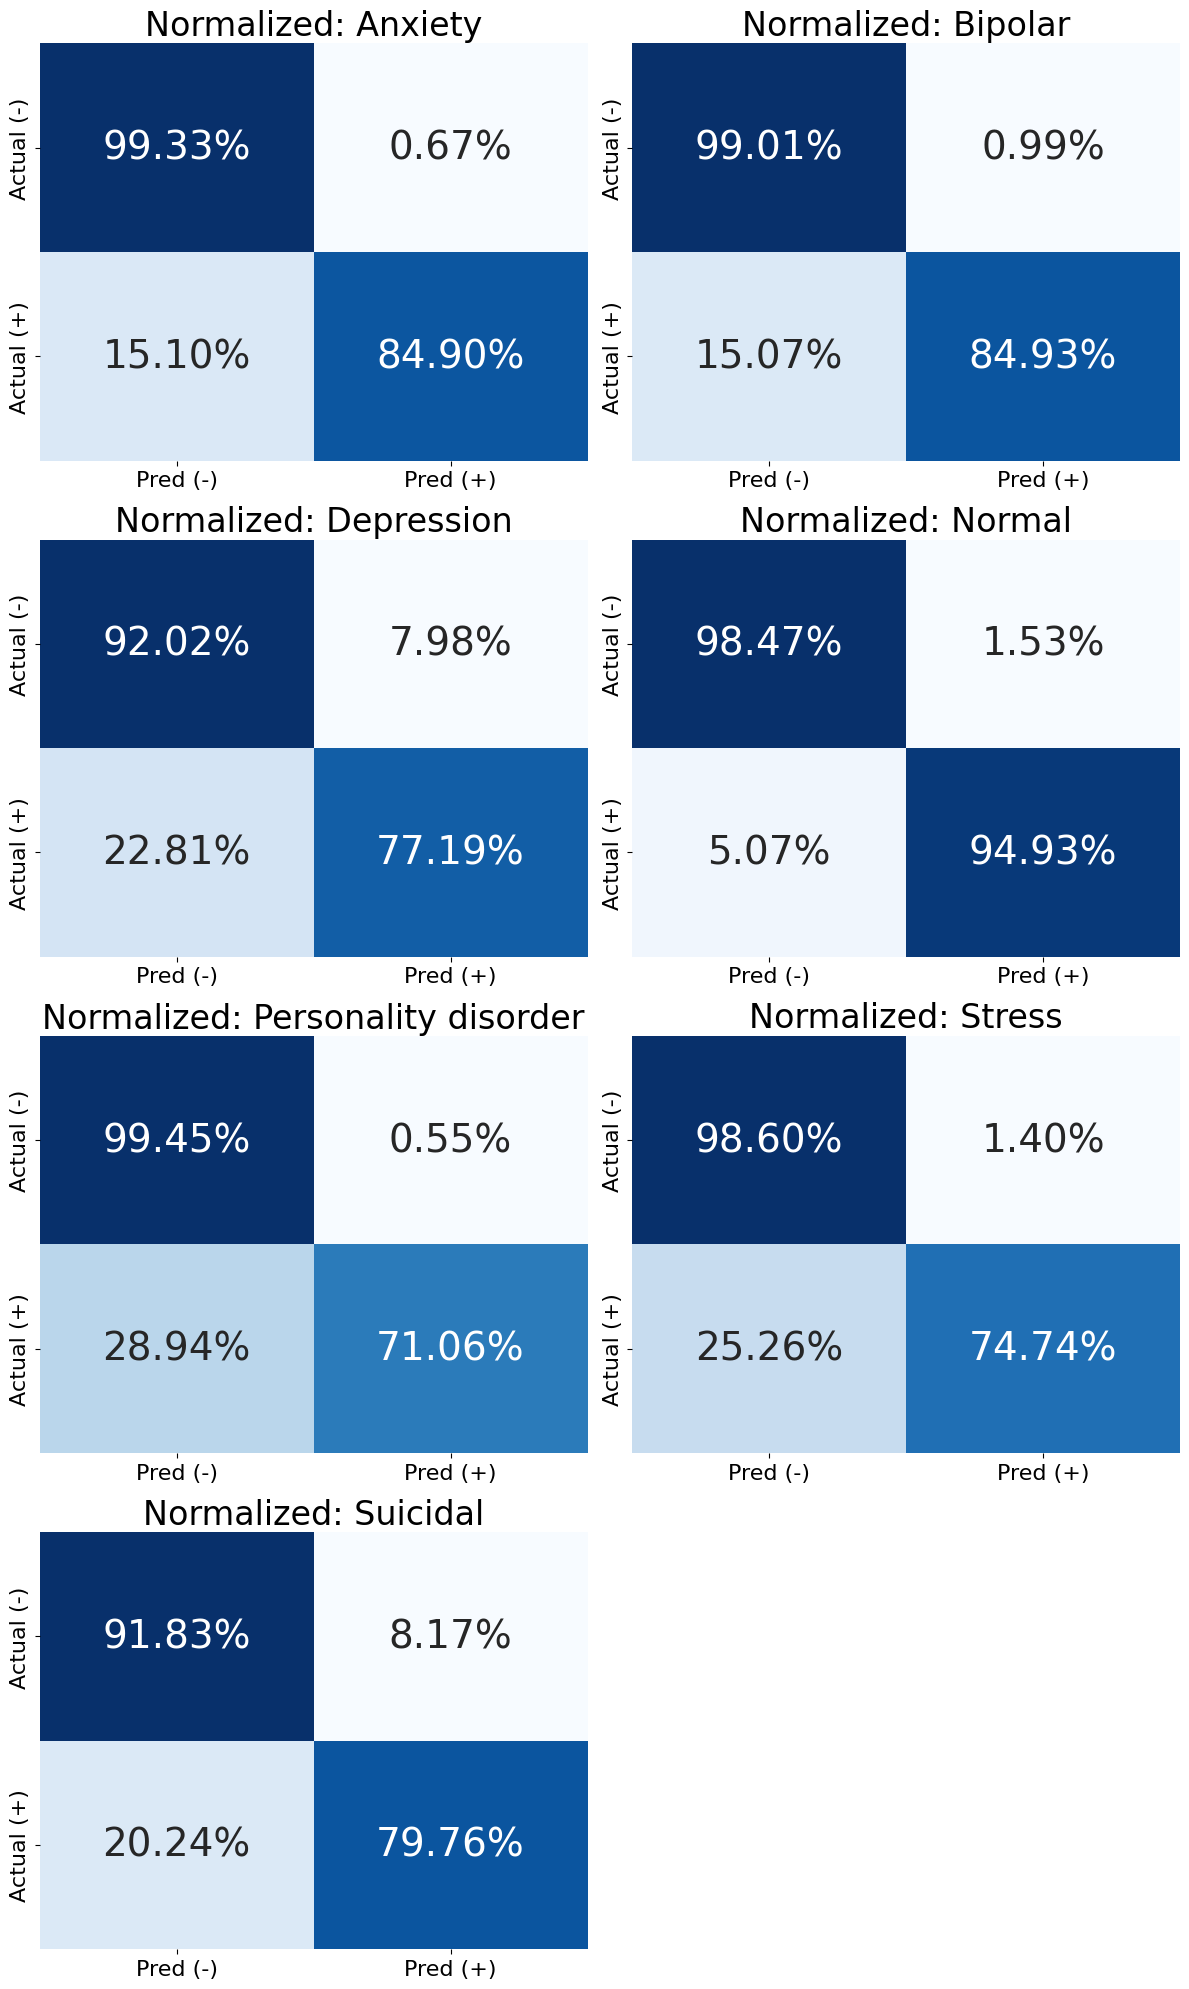

In [ ]:
plot_normalized_mcm(full_mcm_1, label_cols)

In [ ]:
small_metrics_summary = calculate_per_class_metrics(full_mcm_1, label_cols)
display(small_metrics_summary)

,Accuracy,Precision,Recall,F1-Score
Anxiety,0.983083,0.906572,0.849020,0.876853
Bipolar,0.983220,0.815668,0.849260,0.832125
Depression,0.876393,0.802355,0.771896,0.786831
Normal,0.973567,0.965935,0.949314,0.957553
Personality disorder,0.989486,0.695842,0.710615,0.703151
Stress,0.975271,0.715298,0.747387,0.730990
Suicidal,0.893114,0.719797,0.797632,0.756718


In [ ]:
for column in small_metrics_summary.columns:
    print(f"Macro {column}: {small_metrics_summary[column].mean()}")

Macro Accuracy: 0.9534475862281162
Macro Precision: 0.8030668321062981
Macro Recall: 0.8107320758248643
Macro F1-Score: 0.8063173318737021


Rerun to get inference using pre-trained weights

In [ ]:
# 1. Setup paths and parameters
checkpoint_dir = file_path + 'checkpoints_cv'
k_folds = 5
last_epoch = 2
label_cols = ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
num_classes = len(label_cols)

# 2. Recreate the Stratified K-Fold using the SAME random_state as training
X = df_small['statement'].values
y = df_small[label_cols].values
np.random.seed(42)
stratifier = IterativeStratification(n_splits=k_folds, order=1)

all_fold_metrics = []
all_mcm = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Evaluating saved checkpoints for df_small with consistent splits...")

for fold, (train_idx, val_idx) in enumerate(stratifier.split(X, y)):
    print(f"\n======================================")
    print(f"       Evaluating Fold {fold + 1} / {k_folds}       ")
    print(f"======================================")

    # Prepare validation data
    val_df = df_small.iloc[val_idx]
    val_dataset = ChunkedDataset(val_df, text_col='statement', label_cols=label_cols)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Re-initialize the model
    model = DualStreamClassifier(
        num_classes=num_classes,
        psychbert=copy.deepcopy(psychbert_model),
        melbert=copy.deepcopy(melbert_model)
    )
    model.to(device)

    # Load the checkpoint for the last epoch of this fold
    checkpoint_path = os.path.join(checkpoint_dir, f'model_fold{fold+1}_epoch{last_epoch}.pt')
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}. Skipping fold.")
        continue

    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_preds = []
    all_labels = []

    # Run inference
    with torch.no_grad():
        for batch in val_loader:
            psych_ids = batch['psych_input_ids'].to(device)
            psych_mask = batch['psych_attention_mask'].to(device)
            mel_ids = batch['mel_input_ids'].to(device)
            mel_mask = batch['mel_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(psych_ids, psych_mask, mel_ids, mel_mask)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    prec_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_mac = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_mic = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    h_loss = hamming_loss(all_labels, all_preds)
    mcm = multilabel_confusion_matrix(all_labels, all_preds)

    all_mcm.append(mcm)

    all_fold_metrics.append({
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_mac,
        'f1_micro': f1_mic,
        'hamming_loss': h_loss
    })

    # Print metrics for the fold
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Macro): {prec_macro:.4f}")
    print(f"Recall (Macro): {rec_macro:.4f}")
    print(f"F1 (Macro): {f1_mac:.4f} | F1 (Micro): {f1_mic:.4f}")
    print(f"Hamming Loss: {h_loss:.4f}")
    print("\nConfusion Matrix per class:")
    for i, class_name in enumerate(label_cols):
        print(f"  {class_name}:")
        print(f"    TN: {mcm[i][0][0]} | FP: {mcm[i][0][1]}")
        print(f"    FN: {mcm[i][1][0]} | TP: {mcm[i][1][1]}")

# Print average metrics across all folds
if all_fold_metrics:
    print("\n======================================")
    print("    AVERAGE METRICS ACROSS ALL FOLDS  ")
    print("======================================")
    print(f"Average Accuracy: {np.mean([m['accuracy'] for m in all_fold_metrics]):.4f}")
    print(f"Average Precision (Macro): {np.mean([m['precision_macro'] for m in all_fold_metrics]):.4f}")
    print(f"Average Recall (Macro): {np.mean([m['recall_macro'] for m in all_fold_metrics]):.4f}")
    print(f"Average F1-Macro: {np.mean([m['f1_macro'] for m in all_fold_metrics]):.4f}")
    print(f"Average F1-Micro: {np.mean([m['f1_micro'] for m in all_fold_metrics]):.4f}")
    print(f"Average Hamming Loss: {np.mean([m['hamming_loss'] for m in all_fold_metrics]):.4f}")
    # 1. Calculate the average confusion matrix across all 5 folds
    average_mcm = np.mean(all_mcm, axis=0)

    # 2. Visualize with the new 2-column layout
    print("Displaying Average Normalized Confusion Matrices (df_small):")
    plot_normalized_mcm(average_mcm, label_cols)


# Test Run Setup for `df_big`
Taking a 10,000-row stratified subset to quickly test the model on the larger dataset's labels and sequence lengths.

In [ ]:
# 1. Define the specific label columns for df_big
label_cols_big = ['Anxiety', 'BPD', 'autism', 'bipolar', 'depression', 'mentalhealth', 'schizophrenia']
num_classes_big = len(label_cols_big)

# 2. Sample a subset for the test run (10,000 rows)
df_big_sample = df_big.sample(n=10000, random_state=42).reset_index(drop=True)

X_big = df_big_sample['Text'].values
y_big = df_big_sample[label_cols_big].values

# 3. Create a single Train/Val split (80/20) using IterativeStratification
np.random.seed(42)
stratifier_big = IterativeStratification(n_splits=5, order=1)
train_idx_big, val_idx_big = next(stratifier_big.split(X_big, y_big))

train_df_big = df_big_sample.iloc[train_idx_big]
val_df_big = df_big_sample.iloc[val_idx_big]

print(f"Test Run Data - Train: {len(train_df_big)}, Val: {len(val_df_big)}")

# 4. Create Datasets and DataLoaders
# Note: df_big uses 'Text' instead of 'statement'
train_dataset_big = ChunkedDataset(train_df_big, text_col='Text', label_cols=label_cols_big)
val_dataset_big = ChunkedDataset(val_df_big, text_col='Text', label_cols=label_cols_big)

# Increasing batch_size to 32 for the A100 GPU
train_loader_big = DataLoader(train_dataset_big, batch_size=32, shuffle=True)
val_loader_big = DataLoader(val_dataset_big, batch_size=32, shuffle=False)

# 5. Re-initialize the Model for df_big
current_psychbert_big = copy.deepcopy(psychbert_model)
current_melbert_big = copy.deepcopy(melbert_model)

model_big = DualStreamClassifier(
    num_classes=num_classes_big,
    psychbert=current_psychbert_big,
    melbert=current_melbert_big
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_big.to(device)

criterion_big = nn.BCEWithLogitsLoss()
optimizer_big = AdamW(model_big.parameters(), lr=2e-5)

print("df_big test run setup is complete! Ready to train.")

Test Run Data - Train: 8000, Val: 2000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


df_big test run setup is complete! Ready to train.


In [ ]:
# Create a specific directory for df_big checkpoints
checkpoint_dir_big = file_path + 'checkpoints_big_testrun'
os.makedirs(checkpoint_dir_big, exist_ok=True)

num_epochs_big = 2 # Keeping it small for the test run

print("Starting Test Run Training for df_big...")

for epoch in range(num_epochs_big):
    model_big.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader_big):
        psych_ids = batch['psych_input_ids'].to(device)
        psych_mask = batch['psych_attention_mask'].to(device)
        mel_ids = batch['mel_input_ids'].to(device)
        mel_mask = batch['mel_attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_big.zero_grad()
        logits = model_big(psych_ids, psych_mask, mel_ids, mel_mask)
        loss = criterion_big(logits, labels)
        loss.backward()
        optimizer_big.step()

        total_loss += loss.item()

        if batch_idx % 500 == 0 and batch_idx > 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader_big)} | Loss: {loss.item():.4f}")

    # --- SAVE CHECKPOINT ---
    checkpoint_path = os.path.join(checkpoint_dir_big, f'model_big_test_epoch{epoch+1}.pt')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model_big.state_dict(),
        'optimizer_state_dict': optimizer_big.state_dict(),
        'loss': total_loss / len(train_loader_big),
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

    avg_loss = total_loss / len(train_loader_big)
    epoch_time = time.time() - start_time
    print(f"--- Epoch {epoch+1} Finished | Avg Loss: {avg_loss:.4f} | Time: {epoch_time:.0f}s ---")

# Evaluate after training
print("\nEvaluating df_big test run on Validation Set...")
metrics_big = evaluate_model(model_big, val_loader_big, device)
print(f"Test Run Results -> F1-Macro: {metrics_big['f1_macro']:.4f} | F1-Micro: {metrics_big['f1_micro']:.4f} | Hamming Loss: {metrics_big['hamming_loss']:.4f}")

Starting Test Run Training for df_big...
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_big/model_big_test_epoch1.pt
--- Epoch 1 Finished | Avg Loss: 0.3234 | Time: 597s ---
Checkpoint saved: /content/drive/MyDrive/FYP/checkpoints_big/model_big_test_epoch2.pt
--- Epoch 2 Finished | Avg Loss: 0.2105 | Time: 597s ---

Evaluating df_big test run on Validation Set...
Test Run Results -> F1-Macro: 0.4493 | F1-Micro: 0.7246 | Hamming Loss: 0.0690


In [ ]:
# 1. Define labels and configuration
label_cols_big = ['Anxiety', 'BPD', 'autism', 'bipolar', 'depression', 'mentalhealth', 'schizophrenia']
num_classes_big = len(label_cols_big)
batch_size = 32
num_epochs_big = 2
learning_rate = 2e-5

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/334 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setup complete. Training on 486475 rows with batch size 32.
Estimated batches per epoch: 15203


# 80/20 train test split for evaluation

In [ ]:
# 1. Define labels for df_big
label_cols_big = ['Anxiety', 'BPD', 'autism', 'bipolar', 'depression', 'mentalhealth', 'schizophrenia']

# 2. Setup Stratifier for an 80/20 split (5 folds, take 1 for test)
X_big_full = df_big['Text'].values
y_big_full = df_big[label_cols_big].values

np.random.seed(42)
stratifier_big_eval = IterativeStratification(n_splits=5, order=1)
train_indices, test_indices = next(stratifier_big_eval.split(X_big_full, y_big_full))

# 3. Create the test DataFrame
df_big_test = df_big.iloc[test_indices].reset_index(drop=True)
print(f"Full df_big size: {len(df_big)}")
print(f"Reserved Test set size: {len(df_big_test)} (approx 20%)")

# 4. Create Dataset and DataLoader for Evaluation
test_dataset_big = ChunkedDataset(df_big_test, text_col='Text', label_cols=label_cols_big)
test_loader_big = DataLoader(test_dataset_big, batch_size=32, shuffle=False)

print("Test set and DataLoader for df_big are ready!")

Full df_big size: 486475
Reserved Test set size: 97282 (approx 20%)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/334 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Test set and DataLoader for df_big are ready!


In [ ]:
# 1. Prepare only the training portion of df_big
# 'train_indices' was generated in the previous step using IterativeStratification
df_big_train = df_big.iloc[train_indices].reset_index(drop=True)
print(f"Original df_big size: {len(df_big)}")

print(f"Refactored Training Set size: {len(df_big_train)}")

# 2. Re-initialize Dataset and DataLoader using the training subset
train_dataset_big_final = ChunkedDataset(df_big_train, text_col='Text', label_cols=label_cols_big)
train_loader_big_final = DataLoader(train_dataset_big_final, batch_size=32, shuffle=True, num_workers=2)

# 3. Initialize a fresh Model
model_big_final = DualStreamClassifier(
    num_classes=len(label_cols_big),
    psychbert=copy.deepcopy(psychbert_model),
    melbert=copy.deepcopy(melbert_model)
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_big_final.to(device)

optimizer_final = AdamW(model_big_final.parameters(), lr=2e-5)
criterion_final = nn.BCEWithLogitsLoss()

# 4. Setup specialized checkpoint directory
checkpoint_dir_final = file_path + 'checkpoints_big_final'
os.makedirs(checkpoint_dir_final, exist_ok=True)

# 5. Training Loop
num_epochs_final = 2
print("Starting training on 80% split...")

for epoch in range(num_epochs_final):
    model_big_final.train()
    total_loss = 0
    start_time = time.time()

    for batch_idx, batch in enumerate(train_loader_big_final):
        psych_ids = batch['psych_input_ids'].to(device)
        psych_mask = batch['psych_attention_mask'].to(device)
        mel_ids = batch['mel_input_ids'].to(device)
        mel_mask = batch['mel_attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer_final.zero_grad()
        logits = model_big_final(psych_ids, psych_mask, mel_ids, mel_mask)
        loss = criterion_final(logits, labels)
        loss.backward()
        optimizer_final.step()

        total_loss += loss.item()

        if batch_idx % 500 == 0 and batch_idx > 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1}/{num_epochs_final} | Batch {batch_idx}/{len(train_loader_big_final)} | Loss: {loss.item():.4f} | Time: {elapsed:.0f}s")

    # Save Checkpoint
    save_path = os.path.join(checkpoint_dir_final, f'model_final_epoch{epoch+1}.pt')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model_big_final.state_dict(),
        'optimizer_state_dict': optimizer_final.state_dict(),
        'loss': total_loss / len(train_loader_big_final),
    }, save_path)

    avg_loss = total_loss / len(train_loader_big_final)
    print(f"--- Epoch {epoch+1} Finished | Avg Loss: {avg_loss:.4f} | Checkpoint: {save_path} ---")

Original df_big size: 486475
Refactored Training Set size: 389209


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Starting training on 80% split...
Epoch 1/2 | Batch 500/12163 | Loss: 0.1942 | Time: 1142s
Epoch 1/2 | Batch 1000/12163 | Loss: 0.1157 | Time: 2281s
Epoch 1/2 | Batch 1500/12163 | Loss: 0.2014 | Time: 3420s
Epoch 1/2 | Batch 2000/12163 | Loss: 0.1719 | Time: 4560s
Epoch 1/2 | Batch 2500/12163 | Loss: 0.1382 | Time: 5699s
Epoch 1/2 | Batch 3000/12163 | Loss: 0.2212 | Time: 6838s
Epoch 1/2 | Batch 3500/12163 | Loss: 0.1610 | Time: 7977s
Epoch 1/2 | Batch 4000/12163 | Loss: 0.2114 | Time: 9116s
Epoch 1/2 | Batch 4500/12163 | Loss: 0.2463 | Time: 10255s
Epoch 1/2 | Batch 5000/12163 | Loss: 0.1130 | Time: 11394s
Epoch 1/2 | Batch 5500/12163 | Loss: 0.1378 | Time: 12533s
Epoch 1/2 | Batch 6000/12163 | Loss: 0.1627 | Time: 13673s
Epoch 1/2 | Batch 6500/12163 | Loss: 0.1761 | Time: 14812s
Epoch 1/2 | Batch 7000/12163 | Loss: 0.1404 | Time: 15951s
Epoch 1/2 | Batch 7500/12163 | Loss: 0.2200 | Time: 17090s
Epoch 1/2 | Batch 8000/12163 | Loss: 0.1911 | Time: 18229s
Epoch 1/2 | Batch 8500/12163 | 

In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

label_cols_big = ['Anxiety', 'BPD', 'autism', 'bipolar', 'depression', 'mentalhealth', 'schizophrenia']

# Initialize a fresh Model
model_big_final = DualStreamClassifier(
    num_classes=len(label_cols_big),
    psychbert=copy.deepcopy(psychbert_model),
    melbert=copy.deepcopy(melbert_model)
)
model_big_final.to(device)

# Path to the final model checkpoint from the 80/20 split training
checkpoint_path = file_path + 'checkpoints_big_final/model_final_epoch2.pt'

print(f"Loading checkpoint for evaluation: {checkpoint_path}")
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_big_final.load_state_dict(checkpoint['model_state_dict'])
    print("Checkpoint loaded successfully.")
else:
    print("Warning: Checkpoint not found. Evaluating with current model weights.")

model_big_final.eval()

all_preds = []
all_labels = []

print("\nRunning inference on the test set... This might take a while.")
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader_big):
        psych_ids = batch['psych_input_ids'].to(device)
        psych_mask = batch['psych_attention_mask'].to(device)
        mel_ids = batch['mel_input_ids'].to(device)
        mel_mask = batch['mel_attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model_big_final(psych_ids, psych_mask, mel_ids, mel_mask)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

        if batch_idx % 200 == 0 and batch_idx > 0:
            print(f"  Processed {batch_idx}/{len(test_loader_big)} batches")

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# Calculate overall metrics
acc = accuracy_score(all_labels, all_preds)
prec_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1_mac = f1_score(all_labels, all_preds, average='macro', zero_division=0)
f1_mic = f1_score(all_labels, all_preds, average='micro', zero_division=0)
h_loss = hamming_loss(all_labels, all_preds)
mcm = multilabel_confusion_matrix(all_labels, all_preds)

print("\n======================================")
print("       Final Test Set Evaluation      ")
print("======================================")
print(f"Accuracy:          {acc:.4f}")
print(f"Precision (Macro): {prec_macro:.4f}")
print(f"Recall (Macro):    {rec_macro:.4f}")
print(f"F1 Score (Macro):  {f1_mac:.4f}")
print(f"F1 Score (Micro):  {f1_mic:.4f}")
print(f"Hamming Loss:      {h_loss:.4f}")

print("\n======================================")
print("      Confusion Matrix per Class      ")
print("======================================")
for i, class_name in enumerate(label_cols_big):
    print(f"\nClass: {class_name}")
    print(f"  TN: {mcm[i][0][0]:<7} | FP: {mcm[i][0][1]}")
    print(f"  FN: {mcm[i][1][0]:<7} | TP: {mcm[i][1][1]}")


Loading checkpoint for evaluation: /content/drive/MyDrive/FYP/checkpoints_big_final/model_final_epoch2.pt
Checkpoint loaded successfully.

Running inference on the test set... This might take a while.
  Processed 200/3041 batches
  Processed 400/3041 batches
  Processed 600/3041 batches
  Processed 800/3041 batches
  Processed 1000/3041 batches
  Processed 1200/3041 batches
  Processed 1400/3041 batches
  Processed 1600/3041 batches
  Processed 1800/3041 batches
  Processed 2000/3041 batches
  Processed 2200/3041 batches
  Processed 2400/3041 batches
  Processed 2600/3041 batches
  Processed 2800/3041 batches
  Processed 3000/3041 batches

       Final Test Set Evaluation      
Accuracy:          0.8307
Precision (Macro): 0.8669
Recall (Macro):    0.7399
F1 Score (Macro):  0.7903
F1 Score (Micro):  0.8533
Hamming Loss:      0.0412

      Confusion Matrix per Class      

Class: Anxiety
  TN: 77710   | FP: 2349
  FN: 2577    | TP: 14646

Class: BPD
  TN: 89046   | FP: 605
  FN: 2278    

In [ ]:
import numpy as np

# Reconstructing the multi-label confusion matrix (mcm) for df_big final results
# Format per class: [[TN, FP], [FN, TP]]
mcm_big = np.array([
    [[77710, 2349], [2577, 14646]],   # Anxiety
    [[89046, 605], [2278, 5353]],     # BPD
    [[95784, 71], [201, 1226]],       # autism
    [[88448, 616], [2406, 5812]],     # bipolar
    [[38669, 6977], [2722, 48914]],   # depression
    [[88512, 916], [4777, 3077]],     # mentalhealth
    [[93203, 581], [972, 2526]]       # schizophrenia
])
label_cols_big = ['Anxiety', 'BPD', 'autism', 'bipolar', 'depression', 'mentalhealth', 'schizophrenia']

print("Reconstructed MCM for df_big. Shape:", mcm_big.shape)

Reconstructed MCM for df_big. Shape: (7, 2, 2)


In [ ]:
# Calculate for the large dataset
big_metrics_summary = calculate_per_class_metrics(mcm_big, label_cols_big)
display(big_metrics_summary)

,Accuracy,Precision,Recall,F1-Score
Anxiety,0.949364,0.861783,0.850374,0.856041
BPD,0.970365,0.898456,0.701481,0.787843
autism,0.997204,0.945258,0.859145,0.900147
bipolar,0.968936,0.904169,0.707228,0.793664
depression,0.900300,0.875168,0.947285,0.909799
mentalhealth,0.941479,0.770599,0.391775,0.519456
schizophrenia,0.984036,0.813003,0.722127,0.764875


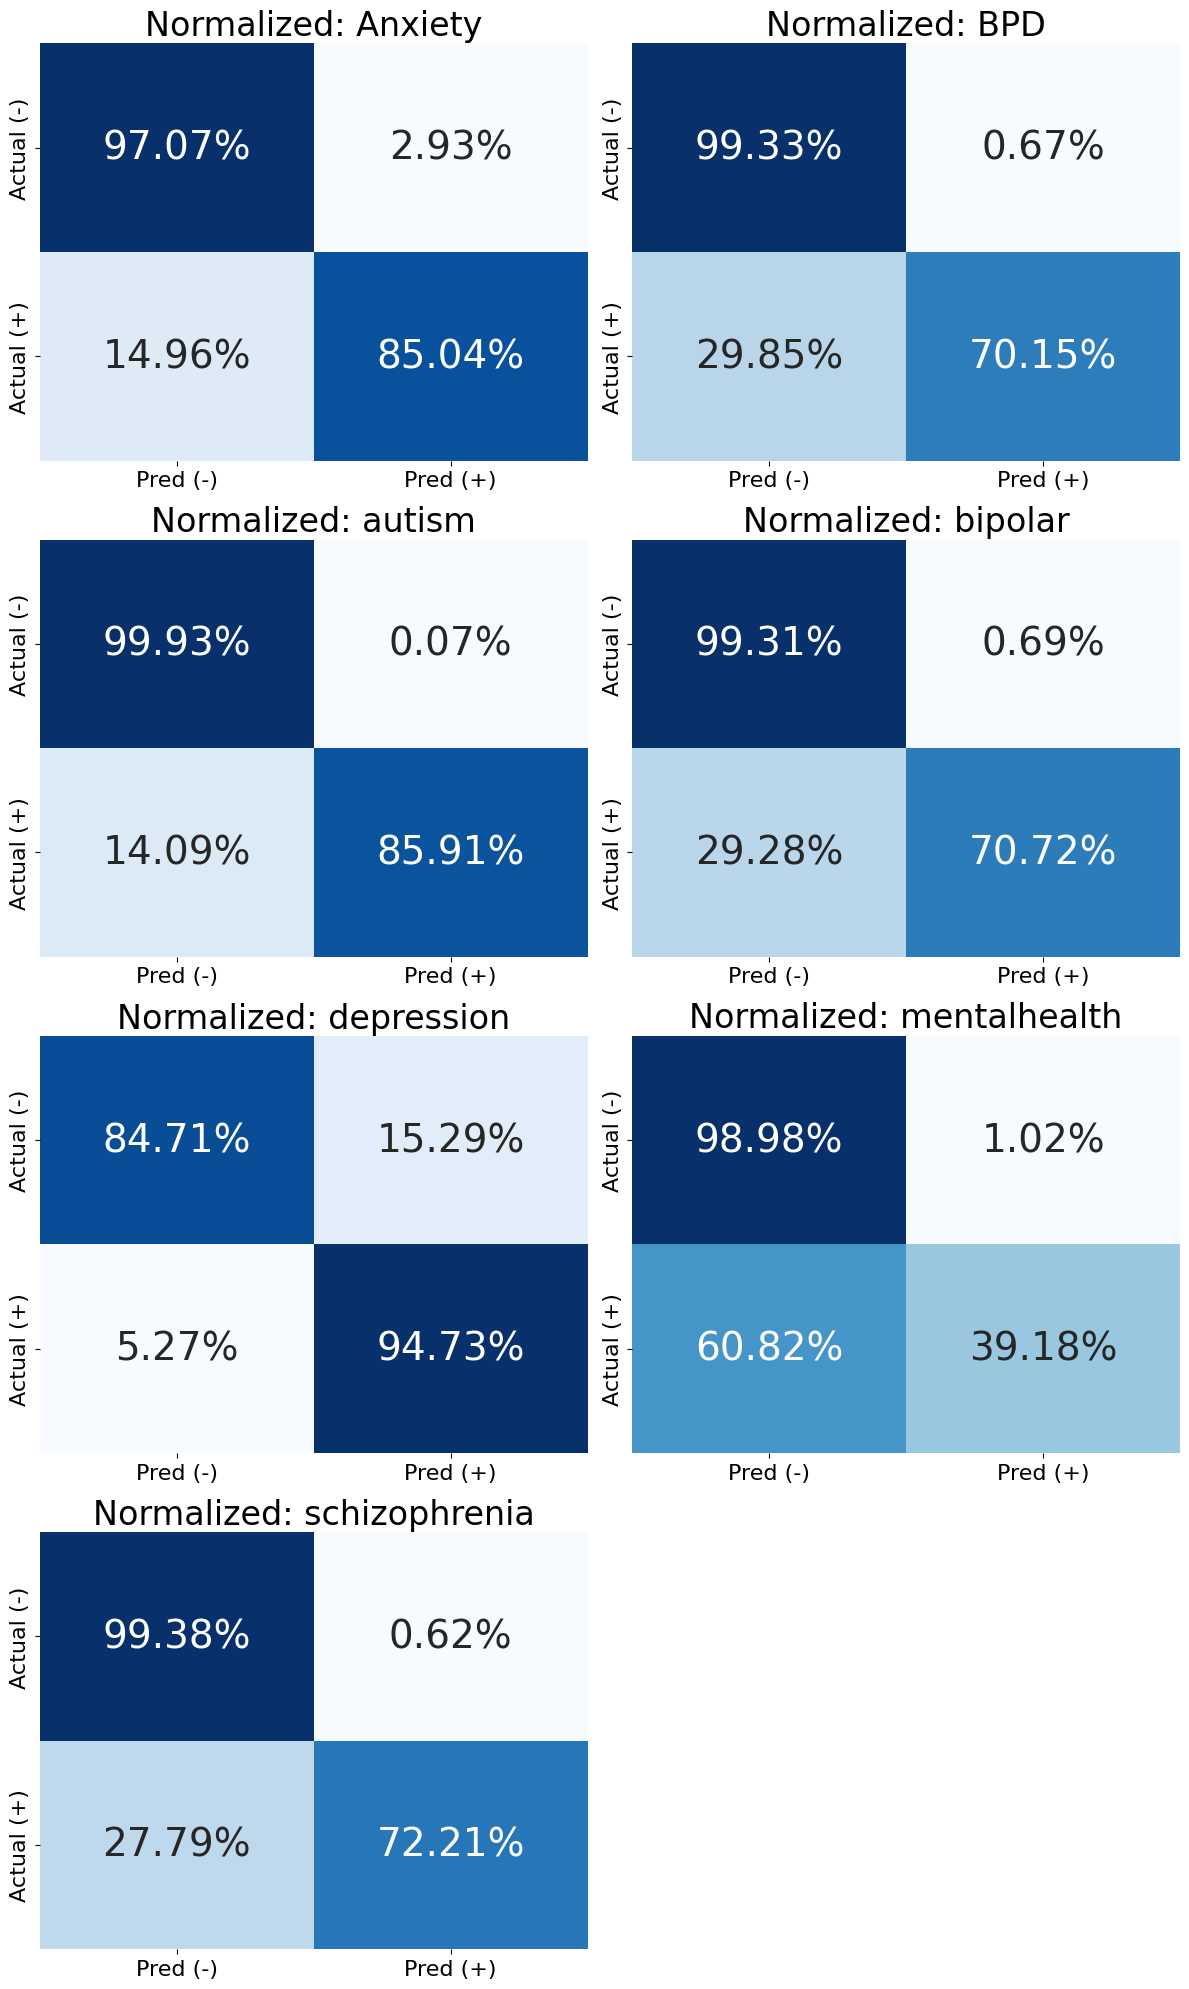

In [ ]:
# Execute the plot using the results from the evaluation cell
plot_normalized_mcm(mcm_big, label_cols_big)

# Clear GPU Memory

In [ ]:
import gc

del model
del optimizer
torch.cuda.empty_cache()
gc.collect()

print("GPU memory cleared.")

NameError: name 'model' is not defined